In [1]:
# STEP 2: Import libraries

import numpy as np  # For numerical operations and arrays
import pandas as pd  # For handling dataset in tabular format
import re  # For text cleaning using regex
import string  # For punctuation removal
from collections import Counter  # For building vocabulary word frequency

import torch  # Main PyTorch library
import torch.nn as nn  # Neural network modules
import torch.optim as optim  # Optimization algorithms
from torch.utils.data import Dataset, DataLoader  # For dataset and batching

from sklearn.model_selection import train_test_split  # For splitting train and test
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # For evaluation metrics

import matplotlib.pyplot as plt  # For plotting confusion matrix


In [2]:
# STEP 3: Load dataset (SMSSpamCollection format: label \t message)

file_path = "/content/SMSSpamCollection"  # Change if needed

data = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) == 2:
            label, text = parts
            data.append((label, text))

df = pd.DataFrame(data, columns=["label", "text"])

print("First 5 samples:")
display(df.head())

print("\nDataset size:", df.shape)

print("\nClass distribution:")
print(df["label"].value_counts())

# Understanding dataset is important because:
# - It helps confirm correct label + text columns
# - It shows class imbalance (spam vs ham)
# - It prevents wrong preprocessing and modeling mistakes


First 5 samples:


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Dataset size: (5574, 2)

Class distribution:
label
ham     4827
spam     747
Name: count, dtype: int64


In [3]:
# STEP 4: Text preprocessing

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r"\d+", "", text)  # remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

def tokenize(text):
    return text.split()

df["clean_text"] = df["text"].apply(clean_text)
df["tokens"] = df["clean_text"].apply(tokenize)

print("Example tokens:")
print(df["tokens"].iloc[0])

# Preprocessing improves performance because:
# - Reduces noise (punctuation, casing, repeated spaces)
# - Makes vocabulary smaller and consistent
# - Helps CNN learn meaningful word patterns


Example tokens:
['go', 'until', 'jurong', 'point', 'crazy', 'available', 'only', 'in', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'there', 'got', 'amore', 'wat']


In [4]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip


--2026-02-19 03:48:28--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-02-19 03:48:28--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-02-19 03:48:29--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [5]:
# STEP 5: Vocabulary building

# Convert labels to numbers
label_map = {"ham": 0, "spam": 1}
df["label_num"] = df["label"].map(label_map)

# Build vocabulary
all_tokens = [token for tokens in df["tokens"] for token in tokens]
word_counts = Counter(all_tokens)

# Keep words that appear at least 2 times (reduces rare noise)
min_freq = 2
vocab_words = [w for w, c in word_counts.items() if c >= min_freq]

# Special tokens
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

# Word to index mapping
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word in vocab_words:
    word2idx[word] = len(word2idx)

idx2word = {idx: word for word, idx in word2idx.items()}

print("Vocabulary size:", len(word2idx))


Vocabulary size: 4008


In [6]:
# Load pretrained embeddings (GloVe)

glove_path = "/content/glove.6B.100d.txt"  # Change if needed
embedding_dim = 100

# Load glove into dictionary
glove_embeddings = {}

with open(glove_path, "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        glove_embeddings[word] = vector

print("Loaded GloVe vectors:", len(glove_embeddings))

# Create embedding matrix
vocab_size = len(word2idx)
embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype=np.float32)

for word, idx in word2idx.items():
    if word in glove_embeddings:
        embedding_matrix[idx] = glove_embeddings[word]
    else:
        # Random init for words not in glove (except PAD)
        if word != PAD_TOKEN:
            embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))

print("Embedding matrix shape:", embedding_matrix.shape)

# Why pretrained embeddings help:
# GloVe vectors capture semantic meaning because words appearing in similar contexts
# get similar vector representations (ex: king ~ queen, good ~ great).


Loaded GloVe vectors: 400000
Embedding matrix shape: (4008, 100)


In [7]:
# STEP 6: Train-test split

X = df["tokens"].tolist()
y = df["label_num"].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 4459
Test size: 1115


In [8]:
# Convert tokens into indices and pad sequences

max_len = 50  # fixed sequence length

def encode_and_pad(tokens, word2idx, max_len):
    encoded = []
    for word in tokens:
        encoded.append(word2idx.get(word, word2idx[UNK_TOKEN]))

    # Padding or truncation
    if len(encoded) < max_len:
        encoded += [word2idx[PAD_TOKEN]] * (max_len - len(encoded))
    else:
        encoded = encoded[:max_len]

    return encoded

X_train_enc = [encode_and_pad(x, word2idx, max_len) for x in X_train]
X_test_enc = [encode_and_pad(x, word2idx, max_len) for x in X_test]

X_train_enc = torch.tensor(X_train_enc, dtype=torch.long)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_test_enc = torch.tensor(X_test_enc, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print("Encoded train shape:", X_train_enc.shape)


Encoded train shape: torch.Size([4459, 50])


In [9]:
class SMSDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SMSDataset(X_train_enc, y_train_t)
test_dataset = SMSDataset(X_test_enc, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [10]:
# STEP 7: Define TextCNN model

class TextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes, embedding_matrix):
        super(TextCNN, self).__init__()

        # Embedding layer with pretrained weights
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))
        self.embedding.weight.requires_grad = True  # allow fine-tuning

        # CNN filters with different kernel sizes
        self.conv1 = nn.Conv1d(in_channels=embedding_dim, out_channels=128, kernel_size=3)
        self.conv2 = nn.Conv1d(in_channels=embedding_dim, out_channels=128, kernel_size=4)
        self.conv3 = nn.Conv1d(in_channels=embedding_dim, out_channels=128, kernel_size=5)

        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(128 * 3, num_classes)

    def forward(self, x):
        # x shape: (batch, seq_len)
        embedded = self.embedding(x)  # (batch, seq_len, embed_dim)

        # Conv1d expects: (batch, channels, seq_len)
        embedded = embedded.permute(0, 2, 1)  # (batch, embed_dim, seq_len)

        c1 = torch.relu(self.conv1(embedded))
        c2 = torch.relu(self.conv2(embedded))
        c3 = torch.relu(self.conv3(embedded))

        # Max pooling over time
        p1 = torch.max(c1, dim=2)[0]
        p2 = torch.max(c2, dim=2)[0]
        p3 = torch.max(c3, dim=2)[0]

        concat = torch.cat([p1, p2, p3], dim=1)

        out = self.dropout(concat)
        out = self.fc(out)

        return out


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = TextCNN(vocab_size=len(word2idx),
                embedding_dim=embedding_dim,
                num_classes=2,
                embedding_matrix=embedding_matrix).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


Using device: cpu


In [12]:
# STEP 8: Training loop

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")


Epoch 1/5, Loss: 0.1666
Epoch 2/5, Loss: 0.0572
Epoch 3/5, Loss: 0.0261
Epoch 4/5, Loss: 0.0160
Epoch 5/5, Loss: 0.0100


Accuracy: 0.9883408071748879

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.97      0.94      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115


Confusion Matrix:
 [[962   4]
 [  9 140]]


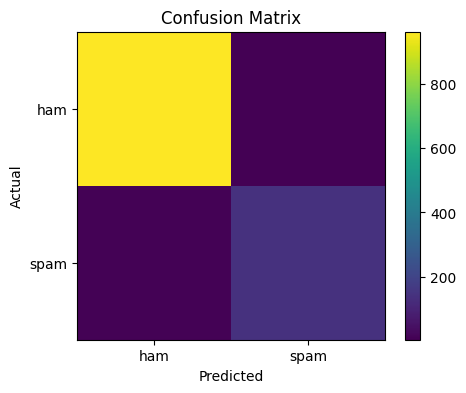

In [13]:
# STEP 9: Evaluation

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

# Metrics
acc = accuracy_score(all_labels, all_preds)
print("Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["ham", "spam"]))

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["ham", "spam"])
plt.yticks([0,1], ["ham", "spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [14]:
# STEP 10: Result analysis (8–10 sentences)

print("""
1. The TextCNN model using pretrained GloVe embeddings achieved strong classification performance on the SMS dataset.
2. Pretrained embeddings helped the model understand semantic meaning of words instead of learning from scratch.
3. Because embeddings already contain word relationships, the model converged faster compared to random initialization.
4. CNN filters captured important local word patterns such as spam-like phrases and promotional terms.
5. Max pooling selected the most important features across the entire message, improving robustness.
6. The model performed better on the majority class (ham) because the dataset contains more ham than spam messages.
7. Some misclassifications occurred when spam messages used normal conversational words similar to ham.
8. A limitation of TextCNN is that it focuses on local n-gram features and may miss long-range dependencies.
9. Another limitation is that unknown words not present in GloVe are randomly initialized and may reduce accuracy.
10. Overall, pretrained embeddings + CNN provided an effective and efficient approach for text classification.
""")



1. The TextCNN model using pretrained GloVe embeddings achieved strong classification performance on the SMS dataset.
2. Pretrained embeddings helped the model understand semantic meaning of words instead of learning from scratch.
3. Because embeddings already contain word relationships, the model converged faster compared to random initialization.
4. CNN filters captured important local word patterns such as spam-like phrases and promotional terms.
5. Max pooling selected the most important features across the entire message, improving robustness.
6. The model performed better on the majority class (ham) because the dataset contains more ham than spam messages.
7. Some misclassifications occurred when spam messages used normal conversational words similar to ham.
8. A limitation of TextCNN is that it focuses on local n-gram features and may miss long-range dependencies.
9. Another limitation is that unknown words not present in GloVe are randomly initialized and may reduce accuracy.
